In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GaussianNoise
from tensorflow.keras import regularizers
from sklearn.metrics import f1_score, precision_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
import yfinance as yf
import joblib
import os
import sys
import warnings
warnings.filterwarnings('ignore')
curr = os.getcwd()
sys.path.append(os.path.abspath(os.path.join(curr, '..')))
from features import FEATURES
from help_folder.backtest import backtest, production_backtest, filter_signals
from help_folder.help import prepare_data, stage1, stage2, calculate_base_features, optimize_threshold, generate_final_report, download, save_models, save_artifacts_json, print_stage_report

In [ ]:
# Параметры
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TICKER = "AAPL"
START_DATE = "2010-01-01"
END_DATE = "2023-12-31"
INTERVAL = "1d"

TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEQUENCE_LENGTH = 60

LSTM_UNITS = 64
DENSE_UNITS = 16
DROPOUT_RATE = 0.5
LEARNING_RATE = 0.0005
BATCH_SIZE = 160
EPOCHS = 30
PATIENCE_ES = 3
PATIENCE_LR = 5

MOVE_THRESHOLD = 0.015
HORIZON = 10

COMMISSION = 0.001
SLIPPAGE = 0.0005
MAX_POSITION_SIZE = 0.1
MAX_DRAWDOWN = 0.15      

MODEL_PATH = '../models/model_lstm'

In [3]:
def create_model(input_dim, name="model_lstm"):
    model = Sequential([
        Input(shape=input_dim),
        GaussianNoise(0.01), 
        
        LSTM(LSTM_UNITS, 
             return_sequences=False,
             kernel_regularizer=regularizers.l2(1e-4),
             recurrent_dropout=0.1),
        BatchNormalization(),
        Dropout(DROPOUT_RATE),
        
        Dense(DENSE_UNITS, 
              activation='relu',
              kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(0.2), 
        
        Dense(1, activation='sigmoid')
    ], name=name)

    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE), 
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [4]:
# ЗАГРУЗКА ДАННЫХ
raw_data, raw_df = download(TICKER, START_DATE, END_DATE, interval=INTERVAL)
print(f"📊 Загружено {len(raw_df)} записей")

spy = yf.download("SPY", start=START_DATE, end=END_DATE, progress=False)
vix = yf.download("^VIX", start=START_DATE, end=END_DATE, progress=False)

spy.columns = spy.columns.get_level_values(0)
vix.columns = vix.columns.get_level_values(0)

# ПОДГОТОВКА ДАННЫХ
print("\n🔧 Подготовка данных...")
df = calculate_base_features(raw_df, spy, vix)
df = df.dropna().reset_index(drop=True)

res_prepare_data = prepare_data(
    df, TRAIN_SPLIT, VAL_SPLIT, SEQUENCE_LENGTH,
    move_threshold=MOVE_THRESHOLD, horizon=HORIZON, FEATURES1=FEATURES
)

📊 Загружено 2768 записей

🔧 Подготовка данных...
✅ Создано 34 признаков. Всего строк: 2768
✅ Train: 1870 | Val: 354 | Test: 354


In [5]:
# STAGE 1: MOVE and HOLD
res_stage1 = stage1(
    res_prepare_data['X_train'], res_prepare_data['X_val'], res_prepare_data['X_test'],
    res_prepare_data['y1_train'], res_prepare_data['y1_val'], res_prepare_data['y1_test'], 
    res_prepare_data['cw1'], res_prepare_data['df_test'],
    create_model=create_model,
    optimize_threshold=optimize_threshold,
    filter_signals=filter_signals,
    EPOCHS=EPOCHS, 
    BATCH_SIZE=BATCH_SIZE, 
    PATIENCE_ES=PATIENCE_ES, 
    PATIENCE_LR=PATIENCE_LR
)


 STAGE 1: MOVE vs HOLD
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.4599 - loss: 0.8898 - val_accuracy: 0.3107 - val_loss: 0.7510 - learning_rate: 5.0000e-04
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5219 - loss: 0.8030 - val_accuracy: 0.4350 - val_loss: 0.7299 - learning_rate: 5.0000e-04
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5604 - loss: 0.7471 - val_accuracy: 0.5282 - val_loss: 0.7010 - learning_rate: 5.0000e-04
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5861 - loss: 0.7426 - val_accuracy: 0.5254 - val_loss: 0.6977 - learning_rate: 5.0000e-04
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5738 - loss: 0.7492 - val_accuracy: 0.5226 - val_loss: 0.7007 - learning_rate: 5.0000e-04
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6043 - loss: 0.6980 - val_accuracy: 0.5621 - val_loss: 0.6823 - learning_rate: 5.0000e-04
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/

In [6]:
# STAGE 2: UP and DOWN
res_stage2 = stage2(
    X_train=res_prepare_data['X_train'],
    X_val=res_prepare_data['X_val'],
    X_test=res_prepare_data['X_test'],
    y2_train=res_prepare_data['y2_train'],
    y2_val=res_prepare_data['y2_val'],
    y2_test=res_prepare_data['y2_test'],
    mask1_train=res_stage1['mask_train'],
    mask1_val=res_stage1['mask_val'],
    mask1_test=res_stage1['mask_test'],
    create_model=create_model,
    optimize_threshold=optimize_threshold,
    EPOCHS=EPOCHS,
    BATCH_SIZE=BATCH_SIZE,
    PATIENCE_ES=PATIENCE_ES,
    PATIENCE_LR=PATIENCE_LR
    # PROB_THRESHOLD_HIGH=PROB_THRESHOLD_HIGH,
    # PROB_THRESHOLD_LOW=PROB_THRESHOLD_LOW
)


 STAGE 2: UP vs DOWN
Stage1 signals → train: 398, val: 22, test: 2
Class weights: {np.int64(0): np.float64(1.6178861788617886), np.int64(1): np.float64(0.7236363636363636)}
Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.3945 - loss: 0.8143 - val_accuracy: 0.6364 - val_loss: 0.6928 - learning_rate: 5.0000e-04
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4774 - loss: 0.7501 - val_accuracy: 0.5909 - val_loss: 0.6833 - learning_rate: 5.0000e-04
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4623 - loss: 0.7661 - val_accuracy: 0.5909 - val_loss: 0.6762 - learning_rate: 5.0000e-04
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4925 - loss: 0.7370 - val_accuracy: 0.5909 - val_loss: 0.6699 - learning_rate: 5.0000e-04
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4799 - loss: 0.7553 - val_accuracy: 0.5909 - val_loss: 0.6652 - learning_rate: 5.0000e-04
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy:

In [7]:
# Оценка
# Stage1
print_stage_report(
    res_prepare_data['y1_test'], 
    res_stage1['preds_test'], 
    "Stage 1 (MOVE vs HOLD)", 
    ['HOLD', 'MOVE']
)

# Stage2
print_stage_report(
    res_stage2['y_true'], 
    res_stage2['preds'], 
    "Stage 2 (UP vs DOWN)", 
    ['DOWN', 'UP']
)


Stage 1 (MOVE vs HOLD):
              precision    recall  f1-score   support

        HOLD       0.23      1.00      0.37        80
        MOVE       1.00      0.01      0.01       274

    accuracy                           0.23       354
   macro avg       0.61      0.50      0.19       354
weighted avg       0.83      0.23      0.09       354


Stage 2 (UP vs DOWN):
              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00         0
          UP       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       0.50      0.50      0.50         2
weighted avg       1.00      1.00      1.00         2



12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


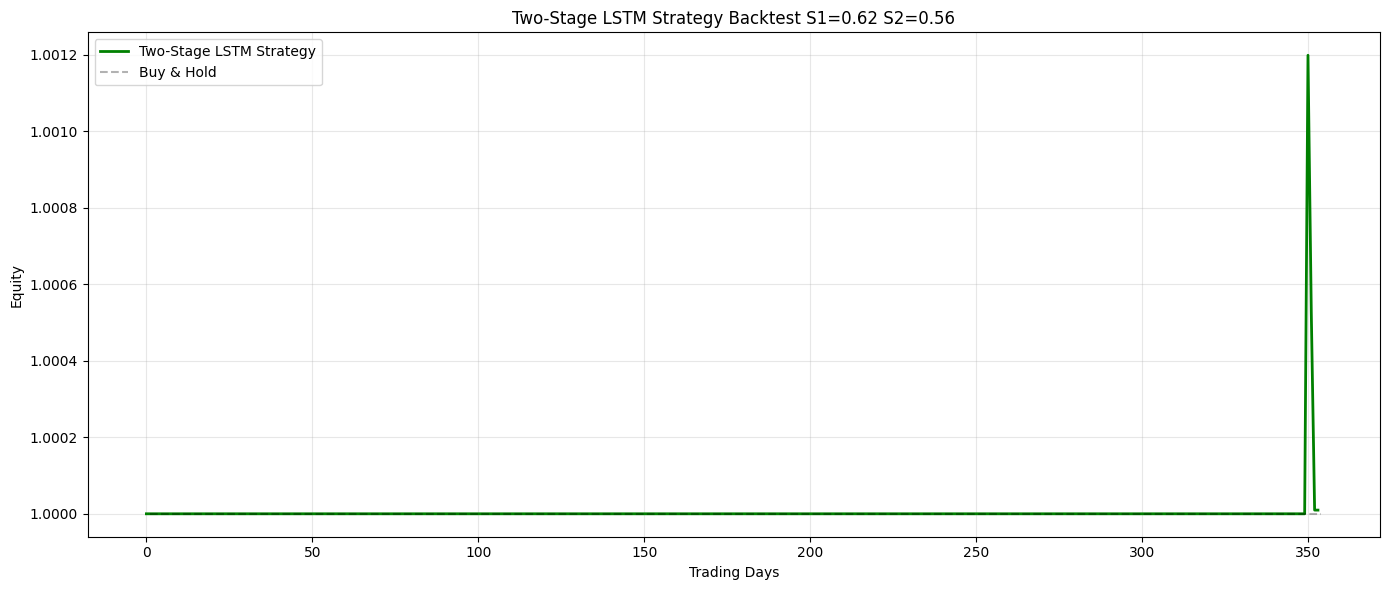

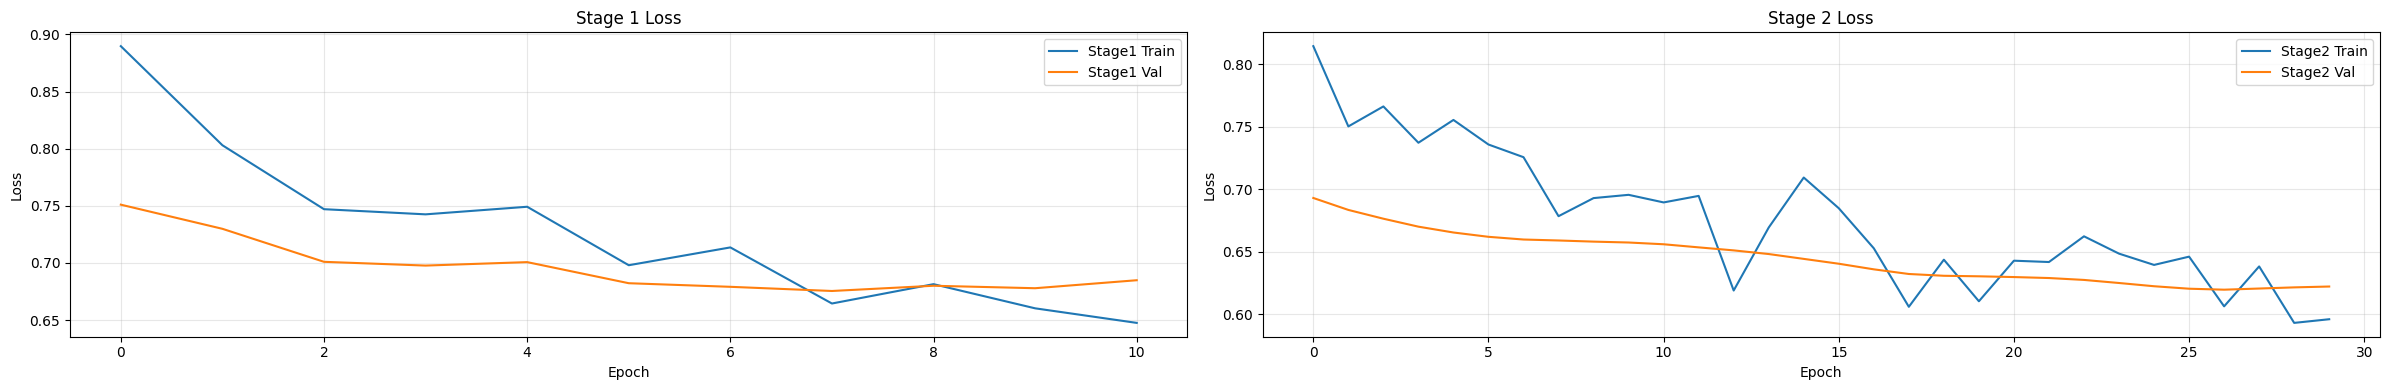

In [8]:
from sklearn.metrics import roc_auc_score

roc_auc_score(res_prepare_data['y1_test'], res_stage1['probs_test'])
roc_auc_score(res_stage2['y_true'], res_stage2['probs'])
probs_full = res_stage2['model'].predict(res_prepare_data['X_test']).flatten()

results = production_backtest(
    res_prepare_data['df_test'], 
    res_stage1['probs_test'], 
    probs_full,
    threshold1=res_stage1['threshold'], 
    threshold2=res_stage2['threshold'],
    commission=COMMISSION, 
    slippage=SLIPPAGE,
    max_position_size=MAX_POSITION_SIZE,
    horizon=HORIZON
)

# backtest с управлением капиталом и рисками
history_stages = [res_stage1['history'], res_stage2['history']]
thresholds = {"S1": res_stage1['threshold'], "S2": res_stage2['threshold']}
backtest(
    results=results,
    history_stages=history_stages,   
    strategy_name="Two-Stage LSTM Strategy",
    thresholds=thresholds,
    save_dir="../models/model_lstm"              
)

In [9]:
# Сохранение модели, scaler и параметров
params = {
    'threshold_stage1': res_stage1['threshold'],
    'threshold_stage2': res_stage2['threshold'],
    'move_threshold': MOVE_THRESHOLD,
    'horizon': HORIZON,
    'commission': COMMISSION,
    'slippage': SLIPPAGE,
    'max_position_size': MAX_POSITION_SIZE,
    'max_drawdown': MAX_DRAWDOWN,
    'sequence_length': SEQUENCE_LENGTH
}

backtest_results = {
    "total_return": results['total_return'],
    "sharpe_ratio": results['sharpe'],
    "max_drawdown": results['max_drawdown'],
    "win_rate": results['win_rate'],
    "trades": results['trades'],
    "avg_pnl": results['avg_pnl']
}

save_artifacts_json(
    base_dir=MODEL_PATH,
    strategy_name="two_stage",
    res_stage1=res_stage1,
    res_stage2=res_stage2,
    FEATURES=FEATURES,
    params=params,
    backtest_results=backtest_results
)

save_models(
    model_stage1=res_stage1['model'],
    model_stage2=res_stage2['model'],
    scaler=res_prepare_data['scaler'],
    params=params,
    base_dir=MODEL_PATH,
    features=FEATURES
)

generate_final_report(
    results=results,
    model_type="two_stage",
    stage1_metrics={
        "threshold": res_stage1['threshold'],
        "f1": res_stage1['f1_val']
    },
    stage2_metrics={
        "threshold": res_stage2['threshold'],
        "f1": res_stage2['f1_val']
    },
    ml_metrics={
        "Stage 1 F1": res_stage1['f1_val'],
        "Stage 2 F1": res_stage2['f1_val']
    }
)

✅ JSON summary saved: ../models/model_lstm/two_stage/artifacts_summary.json
✅ Model Stage 1 saved: ../models/model_lstm/strategy/model_stage1.h5
✅ Model Stage 2 saved: ../models/model_lstm/strategy/model_stage2.h5
✅ Scaler, features, and params (WITH features list) saved to ../models/model_lstm/strategy

📁 Все артефакты сохранены в ../models/model_lstm/strategy

📋 ИТОГОВЫЙ ОТЧЁТ

🎯 Two-Stage Classification:
   Stage 1: MOVE vs HOLD (Threshold=0.6200000000000001, F1=1.0000)
   Stage 2: UP vs DOWN (Threshold=0.56, F1=0.8387)

Метрики:
   Stage 1 F1: 1.0000
   Stage 2 F1: 0.8387

💰 Production Backtest:
   Total Return: 0.0%
   Sharpe Ratio: 0.01
   Max Drawdown: 0.1%
Trades: 1
   Win Rate: 100.0%
